# EDA - Analisis Exploratorio de datos: RRHH

**repaso de todo lo aprendido en el curso**: lectura de ficheros, pandas (exploracion y limpieza) y numpy (operaciones matematicas), y visualizacion con matplotlib, seaborn y plotly.


## StoryTelling: Contexto

Formáis parte del equipo de análisis de datos del departamento de **Recursos Humanos** de una empresa.

Nos han exportado un extracto de la base de datos de personal (`data/empleados_rrhh.csv`) y dirección os pide un **informe exploratorio** para entender cómo está compuesta la plantilla antes de tomar decisiones (revisión salarial, plan de teletrabajo, etc.).

Como en cualquier dataset real, **los datos no llegan limpios**: habrá nulos, departamentos escritos de formas distintas y filas duplicadas. Vamos a seguir el proceso típico de un EDA:

1. Carga de datos
2. Primera exploración
3. Calidad de datos (nulos, duplicados, inconsistencias)
4. Limpieza
5. Análisis univariante (una variable) + visualización
6. Análisis bivariante (relación entre variables) + visualización
7. Correlación entre variables numéricas
8. Un gráfico interactivo con Plotly
9. Conclusiones

## 0.importacion de librerias y configuraciones iniciales

- revisar que nuestro entorno de desarrollo esta activado y que tenemos todas las librerias instaladas

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests as rq

sns.set_theme(style='whitegrid')

## 1.carga de datos

empezamos siempre igual, los datos o bien vienen de base de datos; API; o de un fichero.

In [194]:
df = pd.read_csv('./data/empleados_rrhh.csv')
df.head() # saca los primeros 5 registros

,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
0,79,Beatriz Rubio,Marketing,Hombre,42.0,11.0,32852.78,6.0,18,False
1,151,Ana López,marketing,Hombre,47.0,11.0,36555.44,9.0,1,True
2,172,Teresa Ruiz,ventas,Mujer,52.0,14.0,38518.68,6.0,17,True
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
4,191,Silvia Gómez,VENTAS,Mujer,50.0,14.0,37651.75,5.0,17,True


## 2.primera exploracion

antes de tocar nada, necesitamos entender que tenemos entre manos:
    - cuantas filas 
    - cuantas columnas
    - tipos de datos
    - donde estan los valores numericos

In [195]:
print('dimensiones en filas y columnas', df.shape) # da informacion del numero de filas y columnas
df.info() # resumen de la estructura de un DataFrame.

dimensiones en filas y columnas (230, 10)
<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_empleado       230 non-null    int64  
 1   nombre            230 non-null    str    
 2   departamento      230 non-null    str    
 3   genero            230 non-null    str    
 4   edad              219 non-null    float64
 5   antiguedad_anios  222 non-null    float64
 6   salario_anual     217 non-null    float64
 7   satisfaccion      224 non-null    float64
 8   horas_extra_mes   230 non-null    int64  
 9   teletrabajo       230 non-null    bool   
dtypes: bool(1), float64(4), int64(2), str(3)
memory usage: 16.5 KB


fijaos en dos cosas df.info():
    - hay columnas con menos valores no nulos que filas totales -> tenemos valores nulos
    - comprobar que no hay id de empleados duplicados

### resumen estadistico: todas las estadisticas tipicas: media, mediana, min, max, cuartiles, etc...

In [196]:
df.describe().round(2) # resumen estadistico de el dataframe

,id_empleado,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes
count,230.00,219.00,222.00,217.00,224.00,230.00
mean,111.67,42.13,7.64,36910.99,6.37,9.67
std,63.43,11.57,4.61,18687.84,1.49,5.91
min,1.00,22.00,0.00,18532.34,4.00,0.00
25%,57.25,32.00,4.00,30339.83,5.00,5.00
50%,112.50,42.00,8.00,35393.03,6.00,9.00
75%,165.75,52.00,12.00,39811.86,8.00,15.00
max,220.00,60.00,15.00,235000.00,9.00,20.00


## 3. calidad de los datos

antes de limpiar hay que **detectar** los problemas. vamos a revisar la cantidad de nulos, duplicados

In [197]:
# 3.1. nulos por columna

df.isnull().sum()

id_empleado          0
nombre               0
departamento         0
genero               0
edad                11
antiguedad_anios     8
salario_anual       13
satisfaccion         6
horas_extra_mes      0
teletrabajo          0
dtype: int64

In [198]:
# 3.2. filas duplicadas: mismo empleado registrado mas de una vez.

print('filas duplicadas', df.duplicated().sum())

filas duplicadas 10


In [199]:
# 3.3. cuantos valores distintos tiene departamento? deberia haber solo 5

df['departamento'].value_counts()

departamento
IT            47
Ventas        45
Finanzas      30
Marketing     25
RRHH          19
it            10
marketing      6
 IT            6
VENTAS         5
finanzas       5
It             5
 Ventas        4
rrhh           4
 Marketing     4
MARKETING      3
FINANZAS       3
Rrhh           3
RRHH           3
ventas         2
Finanzas       1
Name: count, dtype: int64

como sospechabamos: el mismo departamento aparece escrito de varias formas. (IT,it). esto es muy habitual cuando los datos se han introducido o vienen de sistemas distintos.

### 4.limpieza de datos

## 4.1. normalizar la columna departamento. quitar espacios en blanco, mayusculas y minusculas

In [200]:
df['departamento'] = df['departamento'].str.strip().str.upper()
print(df['departamento'])

# diccionario de traduccion con el nombre bonito

nombres_departamento = {
    'IT': 'IT',
    'VENTAS': 'Ventas',
    'MARKETING': 'Marketing',
    'RRHH':'RRHH',
    'FINANZAS': 'Finanzas'
}

df['departamento'] = df['departamento'].replace(nombres_departamento)
df['departamento'].value_counts()

0      MARKETING
1      MARKETING
2         VENTAS
3           RRHH
4         VENTAS
         ...    
225       VENTAS
226    MARKETING
227           IT
228     FINANZAS
229           IT
Name: departamento, Length: 230, dtype: str


departamento
IT           68
Ventas       56
Finanzas     39
Marketing    38
RRHH         29
Name: count, dtype: int64

## 4.2. eliminar duplicados


In [201]:
df = df.drop_duplicates()
print('filas tras eliminar duplicados', len(df))
print('duplicado restante', df.duplicated().sum())

filas tras eliminar duplicados 220
duplicado restante 0


## 4.3. tratar los valores nulos

no todos los valores nulos se tratan igual, depende de la columna y tipo de dato.

    - edad, antigüedad_anios, satisfaccion -> los rellenamos con la mediana (es la forma mas robusta de estimar un valor "tipico" sin que nos afecte a los extremos).
    - el salario_anual -> en lugar de usar la mediana global, usamos la mediana pero solo del departamento. usamos group by para agrupar por departamento.
    - nombre, apellidos son susceptibles de eliminarse.

In [202]:
# edad, antigüedad y satisfaccion -> mediana global

for columna in ['edad', 'antiguedad_anios', 'satisfaccion']:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana) # fillna rellena los que no tienen numero (na=no a number), fill(rellena todo sea nulo o no)

# salario -> mediana de todo el departamento
df['salario_anual'] = df['salario_anual'].fillna(
    df.groupby('departamento')['salario_anual'].transform('median')
)

# si tuviesemos que eliminar un registro con valor nulo
# df.dropna() # eliminas todos los nulos

# si quisiera eliminar todo el registro en base a una columna ej-> nombre
# df.dorpna(subset=['nombre', 'apellidos'])

# si quiero eliminar directamente el campo de df
# df.dropna(subset=['nombre'], inplace=True)

# comprobacion final: no deberia quedar ningun null

df.isnull().sum()

id_empleado         0
nombre              0
departamento        0
genero              0
edad                0
antiguedad_anios    0
salario_anual       0
satisfaccion        0
horas_extra_mes     0
teletrabajo         0
dtype: int64

### 5.analisis univariante

## 5.1. empleados por departamento

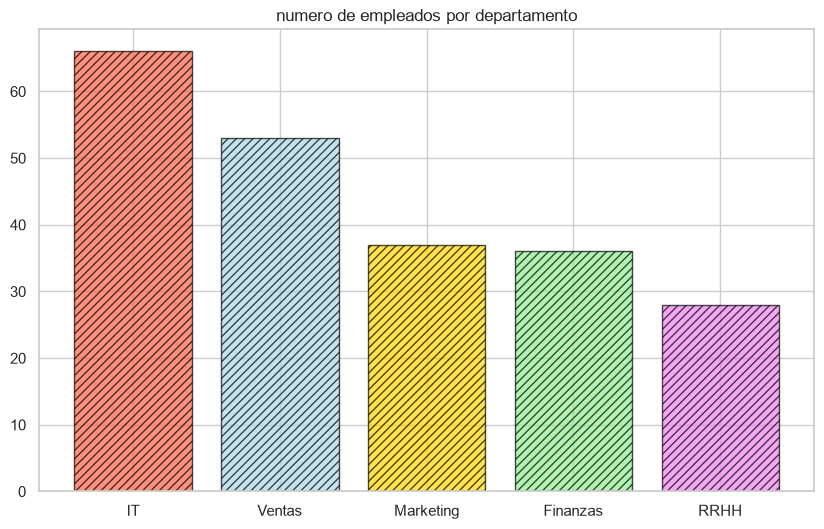

In [203]:
conteo_dpto = df['departamento'].value_counts().reset_index() # reset_index: recuperar los indices
conteo_dpto.columns = ['departamento', 'cantidad']

# matplotlib
plt.figure(figsize=(10,6))
plt.title('numero de empleados por departamento')
plt.bar(conteo_dpto['departamento'], conteo_dpto['cantidad'], alpha=0.7, edgecolor='black', color=['tomato', 'lightblue', 'gold', 'lightgreen', 'violet'], hatch='////')
plt.xlabel='departamento'
plt.ylabel='numero de empleados'
plt.show()

## 5.2. distribucion de la edad

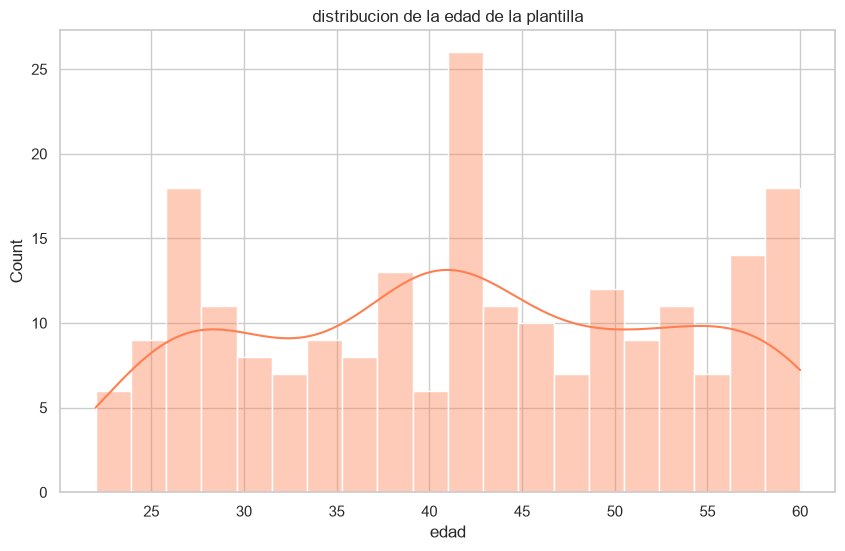

In [204]:
plt.figure(figsize=(10,6))
plt.title('distribucion de la edad de la plantilla')
sns.histplot(
    data=df,
    x='edad',
    kde=True,
    color='coral',
    alpha=0.4,
    bins=20
)



plt.show()

## 5.3. distribucion del salario

vamos a usar boxplot porque nos permite ver la mediana, rango intercualtilico y valores atipicos

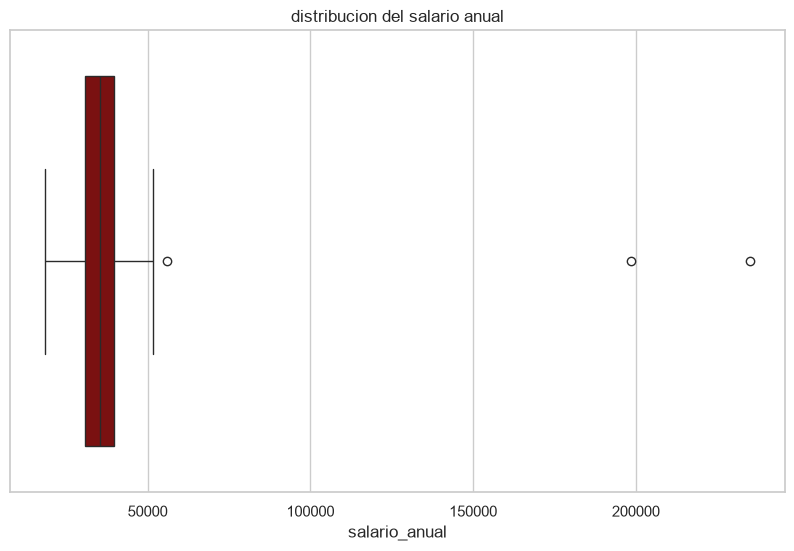

In [205]:
plt.figure(figsize=(10,6))
plt.title('distribucion del salario anual')
sns.boxplot(
    data=df,
    x='salario_anual',
    color='darkred'
)



plt.show()

In [206]:
# quienes son esos outliers que se salen de rango?
df[df['salario_anual'] > 100000] [['nombre', 'departamento', 'antiguedad_anios', 'salario_anual']]

# salario medio:
df['salario_anual'].mean().round(2)

np.float64(36902.47)

## 5.4. reparto por genero

genero
Hombre    118
Mujer     102
Name: count, dtype: int64


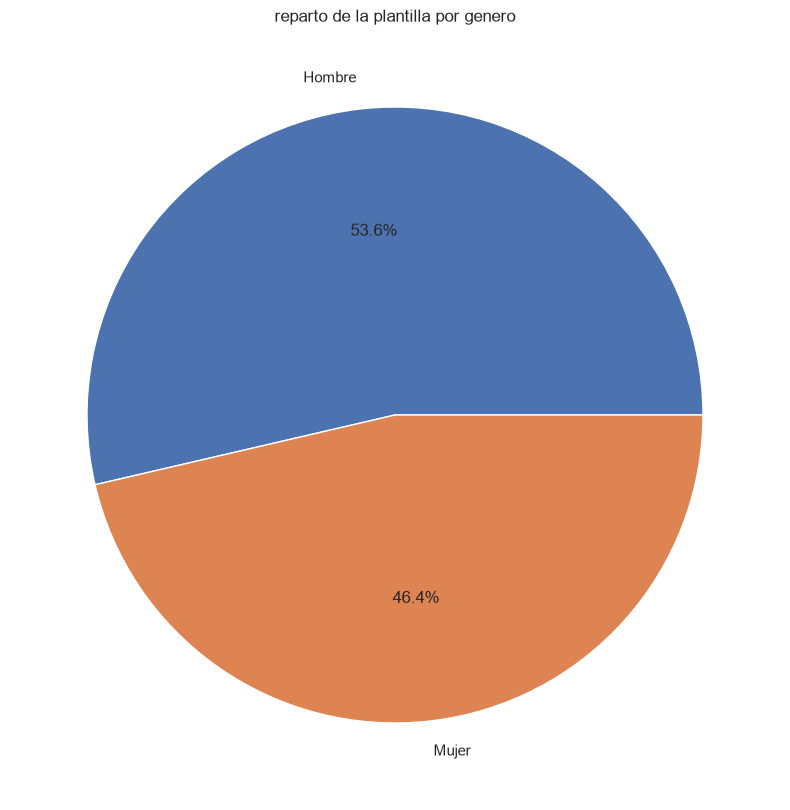

In [207]:
conteo_genero = df['genero'].value_counts()
print(conteo_genero)

plt.figure(figsize=(10,10))
plt.title('reparto de la plantilla por genero')
plt.pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct='%1.1f%%'
)

plt.show()

### 6.analisis bivariante 

vamos a cruzar variables entre si para establecer relaciones.

## 6.1.salario medio por departamento.

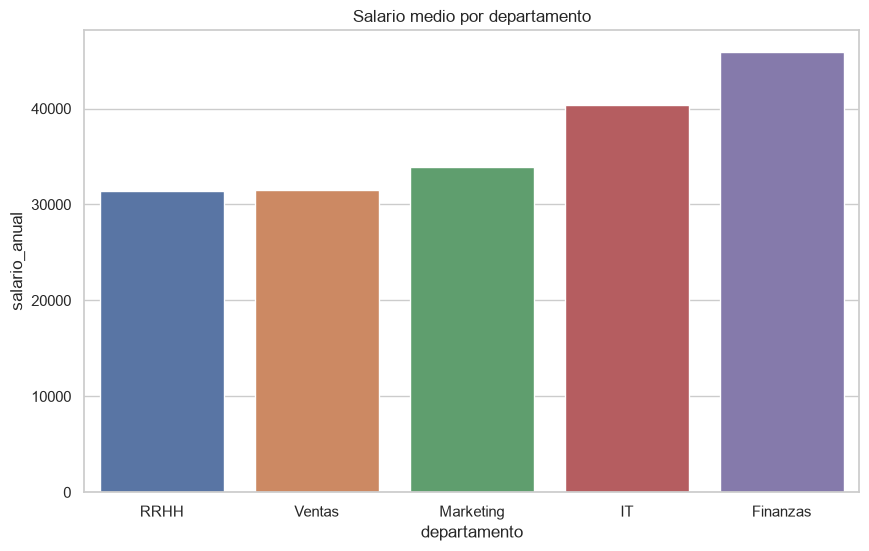

In [208]:
#creacion dataframe nuevo
salario_medio_dpto = (
    df.groupby('departamento')['salario_anual']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('salario_anual', ascending=True)
)

salario_medio_dpto

# salario_medio_dpto los dataFrames no necesitan print
plt.figure(figsize=(10,6))
plt.title('Salario medio por departamento')
sns.barplot(
data=salario_medio_dpto, 
x="departamento", 
y="salario_anual", 
hue="departamento"
)
plt.show()



## 6.2.relacion entre edad y salario

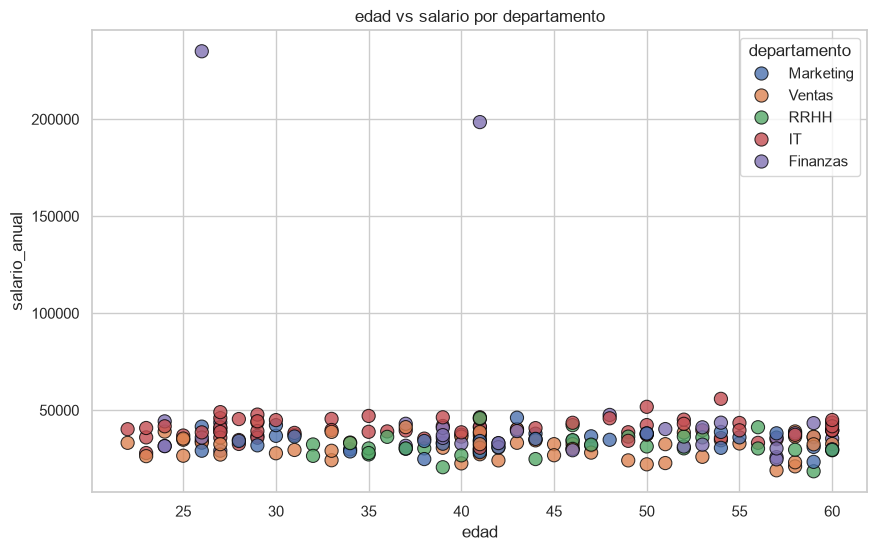

In [209]:
plt.figure(figsize=(10,6))
plt.title('edad vs salario por departamento')
sns.scatterplot(
    data=df,
    x='edad',
    y='salario_anual',
    hue='departamento',
    s=90,
    alpha=0.8,
    edgecolor='black')
plt.show()

## 6.3.influye el teletrabajo en la satisfaccion de los trabajadores?

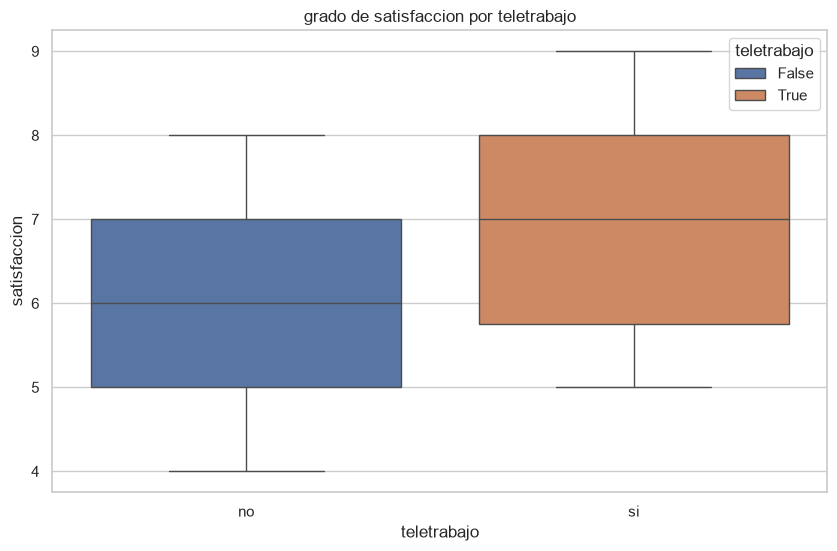

In [210]:
plt.figure(figsize=(10,6))
plt.title('grado de satisfaccion por teletrabajo')
sns.boxplot(
    data=df,
    x='teletrabajo',
    y='satisfaccion',
    hue='teletrabajo'
)
plt.xticks([0,1],['no', 'si'])
plt.show()

### 7.correlacion entre variables numericas

la matriz de correlacion nos dice de un vistazo que variables numericas se mueven juntas

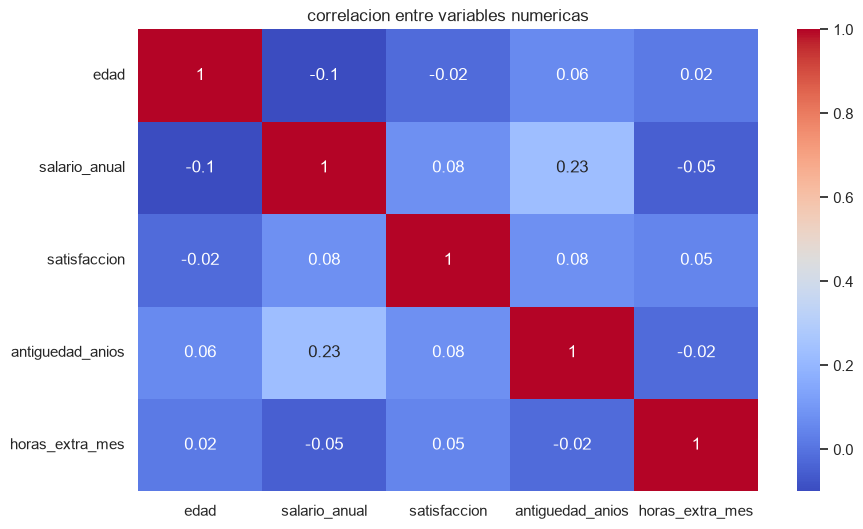

In [211]:
columnas_numericas = ['edad', 'salario_anual', 'satisfaccion', 'antiguedad_anios', 'horas_extra_mes']

matriz_correlacion = df[columnas_numericas].corr().round(2)
plt.figure(figsize=(10,6))
plt.title('correlacion entre variables numericas')
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm'
)
plt.show()

### 8.grafico interactivo con plotly

como ya sabeis con plotly podemos crear el mismo tipo de graficos pero interactivos

In [212]:
fig = px.box(
    df,
    x="departamento",
    y="salario_anual",
    color='departamento',
    points="all",
    title="Distribución del salario por departamento",
    labels={'departamento': 'Departamento', 'salario_anual': 'Salario Anual (€)'}
)

fig.show()

---
## Resumen de funciones utilizadas

| Función / Sintaxis | ¿Para qué sirve? |
|---|---|
| `pd.read_csv()` | Cargar los datos |
| `df.shape` / `df.info()` / `df.describe()` | Primera exploración |
| `df.isnull().sum()` | Contar nulos por columna |
| `df.duplicated()` / `df.drop_duplicates()` | Detectar y eliminar duplicados |
| `df[col].value_counts()` | Distribución de una columna categórica |
| `.str.strip()` / `.str.upper()` / `.replace()` | Normalizar texto |
| `df[col].fillna(valor)` | Rellenar nulos |
| `df.groupby(col).transform()` | Rellenar nulos con un valor por grupo |
| `df.astype()` | Cambiar el tipo de una columna |
| `sns.barplot` / `sns.histplot` / `sns.boxplot` / `sns.scatterplot` / `sns.heatmap` | Visualización estática (seaborn) |
| `plt.pie` | Gráfico de sectores (matplotlib) |
| `df[cols].corr()` | Matriz de correlación |
| `px.box` | Gráfico interactivo (plotly) |
| `requests.get()` / `requests.post()` | Llamar a un webhook de n8n (traer datos / enviar el informe) |

### 9.conclusiones


    

### 10.enviar el informe automatizado

In [213]:
json_data = df.to_json(orient="records")

resumen = {
    "fecha_informe": pd.Timestamp.today().strftime('%d-%m-%Y %H:%M'),
    "total_empleados": len(df),
    "salario_medio": float(df['salario_anual'].mean().round(2)),
    "departamento_mas_grande": df['departamento'].value_counts().idxmax(),
    "numero_empleados_departamento_mas_grande":  int(df['departamento'].value_counts().max()),
    "empleados_hacen_teletrabajo": f"{int(df['teletrabajo'].mean() * 100)}%",
    "data": json_data
}

URL_informe = "https://miriam.n8ncamp.com/webhook-test/montar_informe"

response = rq.post(URL_informe, json=resumen)
conclusiones = response.json()
fichero = open("./data/conclusiones.txt", 'w', encoding='UTF-8')
fichero.write(conclusiones['mensaje'])
fichero.close()
    